# 01 — Dynamic Time Warping (DTW)

*References:*
https://www.youtube.com/watch?v=ERKDHZyZDwA&list=PLmZlBIcArwhMJoGk5zpiRlkaHUqy5dLzL

https://rtavenar.github.io/blog/dtw.html

**What it measures.** DTW is an distance between two series that may run at
different speeds. Instead of comparing sample `i` of `x` only to sample `i` of `y`, it
searches for the cheapest monotone alignment (a *warping path*) between the two index
axes and sums the local costs along it.

**Key idea / formula.** With a local cost `d(x_i, y_j)` (here `|x_i - y_j|`), the
accumulated cost matrix is filled by the recursion

```
D[i, j] = d(x_i, y_j) + min( D[i-1, j],    # go one step in x   (repeat y_j)
                             D[i,   j-1],  # go one step in y   (repeat x_i)
                             D[i-1, j-1] ) # advance both       (a plain match)
```

with `D[0, 0] = 0` and `inf` on the first row and column. `D[n, m]` is the DTW distance,
and back-tracking the arg-min choices yields the optimal warping path.

**What sets DTW apart from EDR/ERP.** DTW sums *real-valued* local costs and has no
tolerance threshold: every pair of aligned samples contributes its full difference. It
therefore reacts strongly to amplitude changes but is largely blind to differences in
sampling rate or timing — the exact opposite trade-off to EDR, which throws the actual
magnitudes away and only counts "close enough / not close enough" (notebook 02).
DTW is *not* a metric: it violates the triangle inequality, which is precisely what ERP
fixes (notebook 03).

In [2]:
import sys
from pathlib import Path

# The notebooks live in `notebooks/`, the packages in the project root.
ROOT = Path.cwd()
if not (ROOT / "data").is_dir():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd

from data.synthetic import generate_dataset
from utils import plotting

%matplotlib inline
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

In [3]:
# Load the shared dataset — identical in all four notebooks (fixed seed).
dataset = generate_dataset()
reference = dataset["reference"]
variants = [name for name in dataset if name != "reference"]

print(f"{'series':>17}  {'length':>6}")
for name, series in dataset.items():
    print(f"{name:>17}  {len(series):>6}")

           series  length
        reference     300
 amplitude_scaled     300
        resampled     390
            noisy     300
    phase_shifted     300
         reversed     300
        unrelated     300


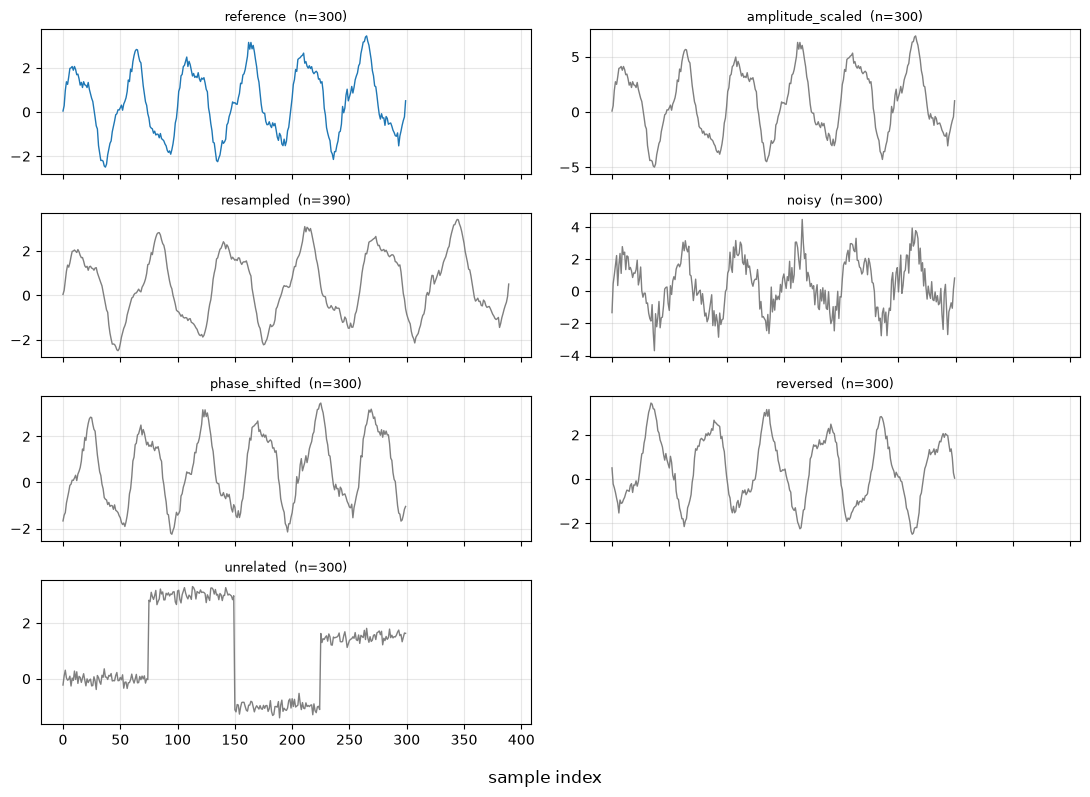

In [4]:
plotting.plot_dataset(dataset)

In [5]:
def dtw_cost_matrix(x: np.ndarray, y: np.ndarray) -> np.ndarray:
    """Accumulated DTW cost matrix for two 1-D series.

    Parameters
    ----------
    x, y : np.ndarray
        The two series, of length ``n`` and ``m``.
    local_cost : {"abs", "squared"}
        Local distance between two samples: ``|x_i - y_j|``.

    Returns
    -------
    np.ndarray
        Matrix ``D`` of shape ``(n + 1, m + 1)``. Row/column 0 are the padding
        border (``D[0, 0] = 0``, the rest ``inf``), so ``D[i, j]`` is the cost of
        optimally aligning ``x[:i]`` with ``y[:j]``.
    """

    n, m = len(x), len(y)
    # All pairwise local costs at once; the DP loop below only does the min().
    diff = x[:, None] - y[None, :]
    d = np.abs(diff)

    D = np.full((n + 1, m + 1), np.inf)
    D[0, 0] = 0.0
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            D[i, j] = d[i - 1, j - 1] + min(D[i - 1, j],      # insertion in x
                                            D[i, j - 1],      # insertion in y
                                            D[i - 1, j - 1])  # match
    return D

In [6]:
def dtw_path(D: np.ndarray) -> list[tuple[int, int]]:
    """Back-track the optimal warping path from an accumulated cost matrix.

    Parameters
    ----------
    D : np.ndarray
        Matrix returned by :func:`dtw_cost_matrix` (including the padding border).

    Returns
    -------
    list[tuple[int, int]]
        Pairs ``(i, j)`` of *series* indices (0-based, border removed), ordered
        from the start of both series to their end.
    """
    i, j = D.shape[0] - 1, D.shape[1] - 1
    path = [(i - 1, j - 1)]
    while i > 1 or j > 1:
        # The border is `inf`, so the arg-min never walks off the matrix.
        step = int(np.argmin([D[i - 1, j - 1], D[i - 1, j], D[i, j - 1]]))
        if step == 0:
            i, j = i - 1, j - 1
        elif step == 1:
            i -= 1
        else:
            j -= 1
        path.append((i - 1, j - 1))
    return path[::-1]


def dtw_distance(x: np.ndarray, y: np.ndarray) -> float:
    """DTW distance between ``x`` and ``y``.

    For ``local_cost="squared"`` the square root of the accumulated cost is
    returned, which is the convention used by the `dtaidistance` package.
    """
    total = dtw_cost_matrix(x, y)[-1, -1]
    return float(np.sqrt(total))

In [7]:
# Sanity check on a tiny hand-checkable example: y is x with one sample repeated,
# so a perfect (zero-cost) warping path must exist.
x_toy = np.array([0.0, 1.0, 2.0, 1.0])
y_toy = np.array([0.0, 1.0, 1.0, 2.0, 1.0])
print("toy distance :", dtw_distance(x_toy, y_toy))
print("toy path     :", dtw_path(dtw_cost_matrix(x_toy, y_toy)))

toy distance : 0.0
toy path     : [(0, 0), (1, 1), (1, 2), (2, 3), (3, 4)]


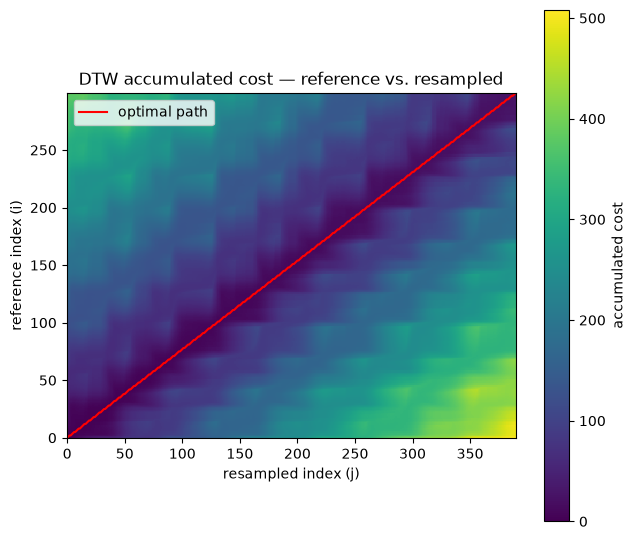

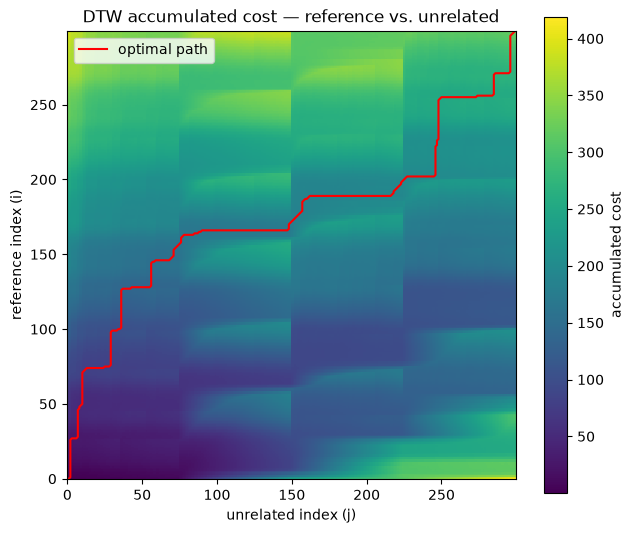

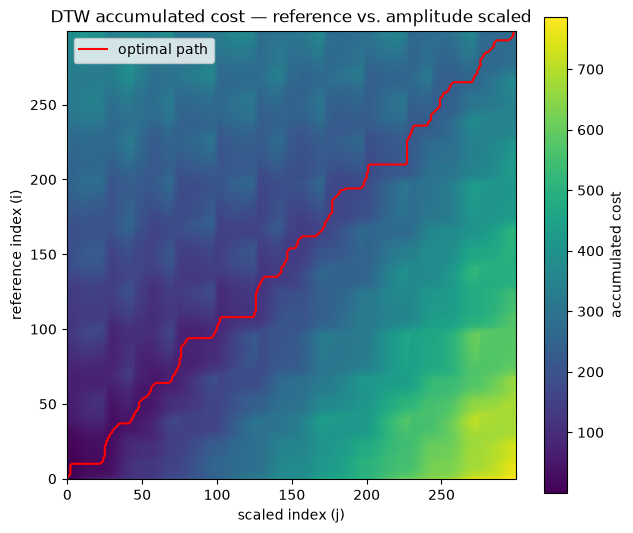

In [11]:
# Visualization: accumulated cost matrix + optimal warping path for three
# contrasting variants — the closest match (`resampled`) and a genuinely 
# different signal (`unrelated`) — so the difference in shape is visible.
D_resampled= dtw_cost_matrix(reference, dataset["resampled"])
path_resampled = dtw_path(D_resampled)

plotting.plot_cost_matrix(
    D_resampled[1:, 1:],  # drop the padding border for plotting
    path=path_resampled,
    title="DTW accumulated cost — reference vs. resampled",
    xlabel="resampled index (j)",
    ylabel="reference index (i)",
)

D_unrelated = dtw_cost_matrix(reference, dataset["unrelated"])
path_unrelated = dtw_path(D_unrelated)

plotting.plot_cost_matrix(
    D_unrelated[1:, 1:],
    path=path_unrelated,
    title="DTW accumulated cost — reference vs. unrelated",
    xlabel="unrelated index (j)",
    ylabel="reference index (i)",
)

D_scaled = dtw_cost_matrix(reference, dataset["amplitude_scaled"])
path_scaled = dtw_path(D_scaled)

plotting.plot_cost_matrix(
    D_scaled[1:, 1:],
    path=path_scaled,
    title="DTW accumulated cost — reference vs. amplitude scaled",
    xlabel="scaled index (j)",
    ylabel="reference index (i)",
)

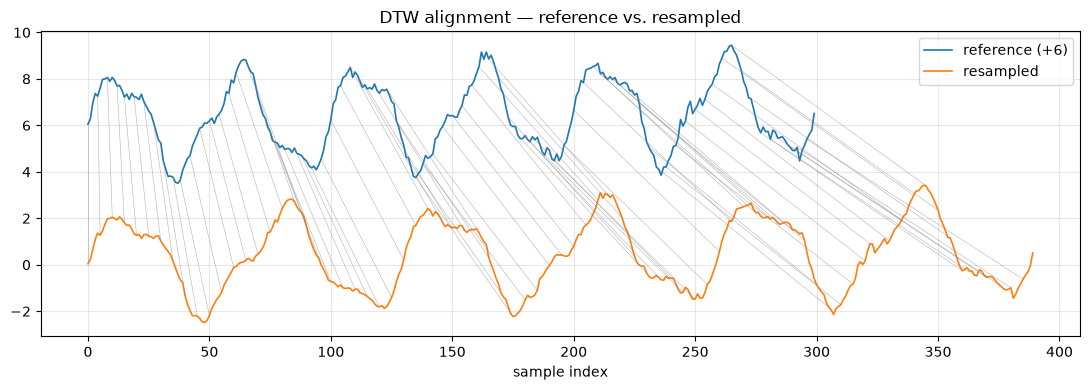

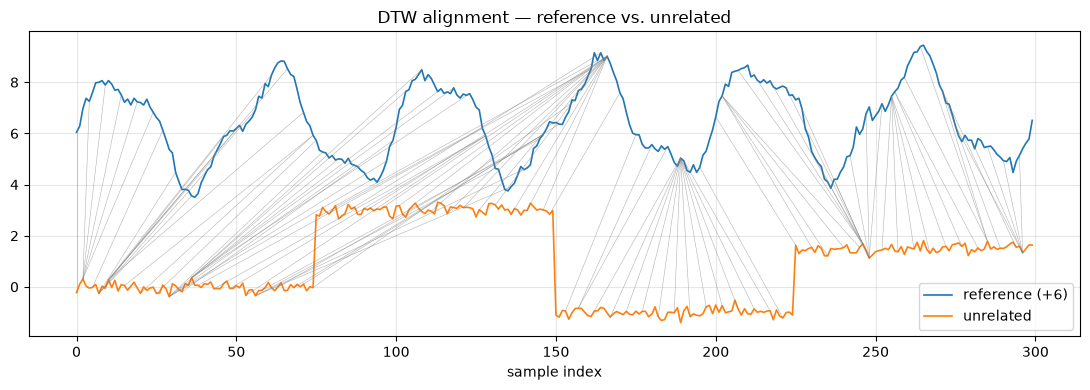

In [12]:
# The same alignments seen on the signals themselves: the grey lines are the
# sample pairs that DTW decided to match.
plotting.plot_alignment(
    reference, dataset["resampled"], path_resampled,
    labels=("reference", "resampled"), every=5,
    title="DTW alignment — reference vs. resampled",
)

plotting.plot_alignment(
    reference, dataset["unrelated"], path_unrelated,
    labels=("reference", "unrelated"), every=5,
    title="DTW alignment — reference vs. unrelated",
)

In [13]:
# Distance from `reference` to every other variant.
# `dtw_norm` divides by the path length, because the raw DTW cost grows with the
# number of aligned pairs and would otherwise punish the longer `resampled` series.
rows = []
for name in variants:
    D = dtw_cost_matrix(reference, dataset[name])
    M = reference.shape[0]
    N = dataset[name].shape[0]
    path = dtw_path(D)
    rows.append({
        "variant": name,
        "dtw": float(D[-1, -1]),
        "norm_divisor": M + N,
        "dtw_norm": float(D[-1, -1]) / (M + N),
    })

dtw_table = pd.DataFrame(rows).set_index("variant").sort_values("dtw")
dtw_table

,dtw,norm_divisor,dtw_norm
variant,,,
resampled,23.310,690,0.034
phase_shifted,83.347,600,0.139
reversed,100.358,600,0.167
noisy,122.133,600,0.204
amplitude_scaled,273.333,600,0.456
unrelated,317.349,600,0.529


## Conclusion

`resampled` (23.3) and `phase_shifted` (83.3) are by far the most similar variants: DTW
is free to stretch and compress the index axis, so a 30 % change in sampling rate or a
constant time offset is absorbed by the warping path at almost no cost. At the other end,
`amplitude_scaled` (273.3) and `unrelated` (317.3) are flagged as clearly dissimilar —
and after normalising by path length the two are practically tied (0.598 vs. 0.599).
That is the recursion talking: DTW sums *real* magnitude differences, so doubling the
amplitude doubles the cost of every single aligned pair, and a merely rescaled signal
ends up looking as foreign as a completely different one.

`noisy` (122.1) sits in the middle, as expected — warping cannot cancel sample-wise
noise, so each aligned pair keeps paying its own small residual. The one result worth
pausing on is `reversed` (100.4), which scores *better* than `noisy`. Our reference is
dominated by a periodic component, and a time-reversed sinusoid is just another sinusoid
with a different phase; only the slow linear drift genuinely disagrees. DTW's monotone
path therefore still finds a fairly cheap alignment. The lesson is that DTW is tolerant
along the *time* axis and strict along the *value* axis, and that on quasi-periodic data
it separates a reversed signal much less sharply than one might hope — notebook 04 shows
a method that fails this case completely.